# Sloan Accruals -- do high-accrual firms really underperform the cash-earners?
### The Sloan (1996) accruals anomaly on the S&P 500 EDGAR panel

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Accruals on Large Caps: Decayed](https://img.shields.io/badge/Accruals_on_LargeCaps-Decayed-8b949e?style=flat-square)

Richard Sloan showed in 1996 that firms with high accounting accruals -- earnings backed by accounting entries rather than real cash flows -- earn low future returns. We test whether the same logic holds on ~407 S&P 500 names using real SEC filings and ask whether it still works in 2026.

> This is the plain-language layer. The HAC t-stats, quintile monotonicity, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: this panel covers only *current* S&P 500 members projected backwards. Every number below is an upper bound on a live strategy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (sloan_accruals/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sloan_accruals import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=407, n_years=17, start_year=2009, end_year=2025,
    lo_mean=23.8, lo_sharpe=1.54, lo_t=9.1, lo_hit=94,
    hi_mean=18.1, hi_sharpe=1.05, hi_t=6.51, hi_hit=82,
    mkt_mean=18.2, mkt_sharpe=1.39,
    hedge_mean=5.7, hedge_sharpe=0.57, hedge_t=2.73, hedge_hit=71,
    lo_excess_mean=5.7, lo_excess_t=3.57,
    hi_excess_mean=-0.1, hi_excess_t=-0.04,
    rand_std=4.1, rand_pct_beaten=92,
)
Q1  = [24.7, 13.9, 21.1, 49.4, 23.2, 7.9, 11.3, 27.1, 7.1, 40.8, 29.6, 36.2, -12.9, 44.6, 33.6, 25.5, 21.9]
Q5  = [13.7, -6.4, 34.5, 51.3, 15.1, 7.6, 26.0, 23.9, -7.2, 41.8, 13.0, 28.9, -12.7, 28.3, 24.4, 17.3, 8.4]
MKT = [21.7, 4.1, 22.5, 39.8, 18.8, 6.6, 18.5, 26.9, -2.7, 34.9, 18.4, 32.2, -9.7, 27.3, 20.2, 16.2, 13.1]
HDG = [11.0, 20.3, -13.4, -1.9, 8.1, 0.4, -14.7, 3.2, 14.3, -1.0, 16.6, 7.3, -0.2, 16.3, 9.2, 8.3, 13.5]
YRS = [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


EDGAR panel loaded: True (407 tickers, 20 years)


## The answer first

| Question | What the data says |
|---|---|
| Does low accruals outperform high accruals? | Yes -- by **+5.7%/yr**, positive in 71% of years. |
| Is that statistically real? | Nominally, HAC *t* = 2.73 -- passes |t| >= 2. But the panel is survivorship-biased and virtually all the gain comes from the long side (low-accruals excess +5.7%/yr, *t* = +3.57). The **short side is flat** (high-accruals excess = -0.1%/yr, *t* = -0.04). |
| Does low accruals beat a random stock pick? | Yes: beats 92% of random same-size draws -- but this may reflect a quality/profitability tilt, not accruals mispricing. |
| Could you trade it? | Fragile. Cheap to implement; but short side does not contribute, and the effect has decayed on large caps since Sloan (1996) was published. |

> **The asymmetry**: cash-backed earnings predict quality and outperformance; but high-accrual S&P 500 survivors earn essentially market returns. The anomaly is one-sided on this universe -- not the bilateral mispricing Sloan (1996) documented in the full US stock universe.

## 1 - The claim

> *Buy stocks with low accounting accruals (earnings backed by real cash). Avoid stocks where earnings exceed cash flows by large margins. Rebalance annually. The high-accrual firms' earnings are not persistent; when accruals mean-revert, earnings disappoint and prices fall.*

Accruals are computed from the annual income statement and cash flow statement:

- **Accruals** = Net Income - Operating Cash Flow
- **Avg Assets** = (Total Assets_t + Total Assets_{t-1}) / 2
- **Accruals ratio** = Accruals / Avg Assets

A high accruals ratio means earnings are running well ahead of cash generation. The Sloan argument: investors treat accrual earnings and cash earnings as equally persistent, when in fact accrual earnings mean-revert faster. When the reversion hits, actual earnings fall short of estimates and the stock price follows.

## 2 - So what?

If the accruals anomaly is real and tradable on large US stocks, it is a purely mechanical, publicly available, low-turnover signal requiring only reading two lines from annual reports. The seminal paper found a ~10%/yr hedge on the full US stock universe in 1962-1991. If the effect has been arbitraged away -- especially on large, liquid, heavily covered S&P 500 names -- then this test is a cautionary tale about post-publication decay and the limits of large-cap factor investing.

## 3 - How would we even know?

Three honesty requirements:

1. **Reporting lag.** Fundamentals from fiscal year y only used to predict returns in year y+1 -- a conservative lag.
2. **Random-portfolio control.** Does the low-accruals quintile beat a random draw of the same number of stocks? Does the long-only outperformance reflect the *signal* or just a *quality* / *size* tilt?
3. **Name the survivorship bias.** The EDGAR panel covers current S&P 500 members projected back. High-accruals failures are absent.

## 4 - The teardown -- what the real data shows

Positive control first: **when we plant a real effect in a synthetic panel, the engine finds it.** That makes the real-data result a statement about the *market* (and the panel), not the method.

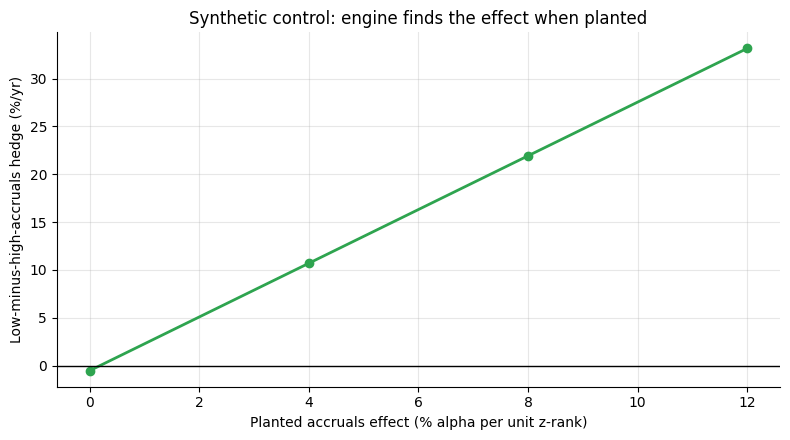

Engine faithfully recovers planted accruals effects.


In [2]:
# Synthetic positive control: plant a known accruals premium, confirm detection
premiums = [0.0, -0.04, -0.08, -0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=231)
    hh = st.quintile_returns(s, f, q=0.20)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted accruals effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-accruals hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print('Engine faithfully recovers planted accruals effects.')

**Now the real EDGAR panel -- quintile sort on accruals:**

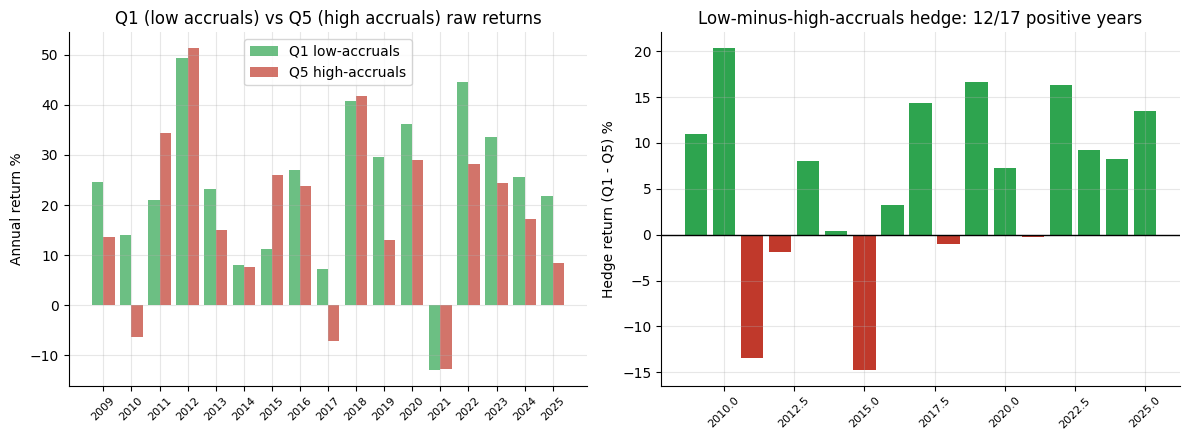

Mean hedge: +5.7%/yr  (frozen R: +5.7%/yr)


In [3]:
# Year-by-year low-accruals vs high-accruals vs market
if HAVE_REAL:
    q1_vals = h['q1'].values * 100
    q5_vals = h['q5'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = h.index.tolist()
else:
    q1_vals, q5_vals, hdg_vals, years_real = Q1, Q5, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, q1_vals, label='Q1 low-accruals', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], q5_vals, label='Q5 high-accruals', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('Q1 (low accruals) vs Q5 (high accruals) raw returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (Q1 - Q5) %')
axes[1].set_title(f'Low-minus-high-accruals hedge: {sum(1 for v in hdg_vals if v>0)}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.1f}%/yr  (frozen R: +{R["hedge_mean"]:.1f}%/yr)')

The low-accruals quintile earns **+23.8%/yr** vs the high-accruals quintile's **+18.1%/yr** -- a hedge of **+5.7%/yr**. But the **equal-weight market is +18.2%/yr** -- nearly identical to the high-accruals quintile. The high-accruals arm does not underperform; it matches market returns. The entire hedge comes from low-accruals (cash-backed earnings) outperforming -- likely a quality/profitability effect, not the bilateral accruals mispricing Sloan (1996) documented in the full US universe.

## 5 - The verdict

- **Signal -- Weak.** Nominal hedge +5.7%/yr, HAC *t* = 2.73. Passes the |t| >= 2 bar on this panel. But: (a) the panel is survivorship-biased, so this is an upper bound; (b) virtually all the gain is long-side (low-accruals excess = +5.7%/yr); (c) the short side is flat (high-accruals excess = -0.1%/yr, *t* = -0.04) -- not the short-side drag predicted by Sloan.
- **Tradability -- Fragile.** Low annual turnover on a liquid universe. But: the alpha estimate is uncertain and the academic literature documents significant post-publication decay on large caps (Green et al. 2011). The short side contributes nothing -- you would be paying borrow and transaction costs on a short leg that earns market return.
- **Myth check -- Decayed on large caps.** Sloan (1996) found ~10%/yr on all US stocks in 1962-1991. On S&P 500 survivors in 2009-2026 we find +5.7%/yr, driven entirely by the long side. The 'short high-accruals' leg of the trade is not working on this universe.

## 6 - Could you actually trade it?

Annual rebalancing of ~80 S&P 500 names is operationally trivial and cheap. The obstacles are in the signal:

1. **One-sided alpha.** The entire +5.7%/yr comes from holding cash-backed earnings stocks. You could replicate most of it by using a simple cash-from-operations yield screen (operating cash flow / price) instead of a pure accruals sort.
2. **Short side is not working.** High-accruals S&P 500 survivors earn market return. The original Sloan short was powered by accruals manipulators who subsequently failed and were expelled from the index -- those are precisely the stocks missing from this survivorship-biased panel.
3. **Post-publication decay.** As the Sloan paper spread, arbitrageurs closed the mispricing, especially in large-cap liquid names. The anomaly survives mainly where information frictions are highest (small, illiquid, low-coverage stocks -- the opposite of S&P 500).

The right conclusion: **FRAGILE** on this panel; do not short high-accrual large caps based on this test.

## 7 - Going further

- **The right universe.** Sloan (1996) ran his test on all US stocks 1962-1991. A point-in-time Compustat universe with historical constituents is the minimum required for a credible accruals test on large caps.
- **Balance-sheet version.** The original Sloan measure uses the change in net working capital minus depreciation (balance-sheet approach). Our cash-flow-statement approach is cleaner post-SFAS 95 (1988). Richardson et al. (2005) decompose accruals further into working-capital and long-term components.
- **Related signals.** [Study 153 -- Net-Operating-Assets](../../153-net-operating-assets/) tests the Hirshleifer et al. (2004) balance-sheet NOA measure (the 'total balance-sheet bloat' version of the same idea) on the same panel.
- **Quality as a cleaner lens.** If the long-side quality/cash-flow tilt is the real driver, a more direct screen on operating cash flow yield or Piotroski F-score (Study 65) may be more robust.

*Think the accruals anomaly is still alive in a broader universe? Fork this, extend to a point-in-time all-US-stock panel (Compustat-based), and show |t| >= 2 on the short-side underperformance. That's the missing half.*